In [1]:
import pandas as pd

# Descargamos los archivos
!gdown 1MV2mivzC_7gLCqRndSnWizXRGhJBgQ6L
!gdown 1GpCc2ggdH9X4nrfbO80ubK4GF5NGtrzk

# Descargamos intelex para acelerar a ScikitLearn
!pip install scikit-learn-intelex -q --progress-bar off
# Descargamos langid
!pip install langid

Downloading...
From: https://drive.google.com/uc?id=1MV2mivzC_7gLCqRndSnWizXRGhJBgQ6L
To: /content/test.csv
100% 11.1M/11.1M [00:00<00:00, 42.5MB/s]
Downloading...
From: https://drive.google.com/uc?id=1GpCc2ggdH9X4nrfbO80ubK4GF5NGtrzk
To: /content/train.csv
100% 72.2M/72.2M [00:01<00:00, 52.3MB/s]
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 37.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for langid: filename=langid-1.1.6-py3-none-any.whl size=1941171 sha256=c4a5661991996022929aec2e0baba3e13bde9db04204d1b7aa26af49bba4f8d4
  Stored in directory: /root/.cache/pip/wheels/3c/bc/9d/266e27289b9019680d65d9b608c37bff1eff565b001c977ec5
Successfully built langid


In [2]:
# Cargamos los archivos en dataframes
data_train = pd.read_csv('train.csv')
data_test = pd.read_csv('test.csv')

print(data_train.info())
data_train

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   ID           50000 non-null  int64 
 1   review_es    50000 non-null  object
 2   sentimiento  50000 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.1+ MB
None


,ID,review_es,sentimiento
0,0,Uno de los otros críticos ha mencionado que de...,positivo
1,1,Una pequeña pequeña producción.La técnica de f...,positivo
2,2,Pensé que esta era una manera maravillosa de p...,positivo
3,3,"Básicamente, hay una familia donde un niño peq...",negativo
4,4,"El ""amor en el tiempo"" de Petter Mattei es una...",positivo
...,...,...,...
49995,49995,Pensé que esta película hizo un buen trabajo a...,positivo
49996,49996,"Mala parcela, mal diálogo, mala actuación, dir...",negativo
49997,49997,Soy católica enseñada en escuelas primarias pa...,negativo
49998,49998,Voy a tener que estar en desacuerdo con el com...,negativo


In [3]:
import langid

def detectar_idioma(texto):
    lang, prob = langid.classify(texto)
    return lang

data_train['idioma'] = data_train['review_es'].apply(detectar_idioma)

In [4]:
X = data_train['review_es']
y = data_train['sentimiento']
x_test = data_test['review_es']

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import numpy as np

X_train_a = np.load("train_emb.npy")
X_test_a = np.load("test_emb.npy")

indices_es = data_train[data_train['idioma'] == 'es'].index

data_train = data_train.loc[indices_es].reset_index(drop=True)
y = data_train['sentimiento']

X_train_emb = X_train_a[indices_es]

print(f"Filas finales tras filtro: {len(data_train)}")
print(f"Dimensiones Embeddings Train: {X_train_emb.shape}")

def get_text_features(df, col_name):
    values = df[col_name].astype(str)
    return np.column_stack([
        values.apply(len),
        values.apply(lambda x: x.count('!')),
        values.apply(lambda x: sum(1 for c in x if c.isupper()) / (len(x) + 1))
    ])

print("Generando features manuales...")
X_train_feats = get_text_features(data_train, 'review_es')
X_test_feats = get_text_features(data_test, 'review_es')

X_train_combined = np.hstack((X_train_emb, X_train_feats))
X_test_combined = np.hstack((X_test_a, X_test_feats))

scaler = StandardScaler()
X_train_final = scaler.fit_transform(X_train_combined)
X_test_final = scaler.transform(X_test_combined)

le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_final,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("Datos listos para entrenar. Shape final:", X_train.shape)

Filas finales tras filtro: 48179
Dimensiones Embeddings Train: (48179, 768)
Generando features manuales...
Datos listos para entrenar. Shape final: (38543, 771)


In [7]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
def testear_clasificacion(y_train, y_test, y_train_pred, y_test_pred):
  metrics = {
      "accuracy": [accuracy_score(y_train, y_train_pred), accuracy_score(y_test, y_test_pred)],
      "precision": [precision_score(y_train, y_train_pred, pos_label=1), precision_score(y_test, y_test_pred, pos_label=1)],
      "recall": [recall_score(y_train, y_train_pred, pos_label=1), recall_score(y_test, y_test_pred, pos_label=1)],
      "f1_score": [f1_score(y_train, y_train_pred, pos_label=1), f1_score(y_test, y_test_pred, pos_label=1)]
  }
  results = pd.DataFrame(metrics, index=["Train", "Test"])

  fig, ax = plt.subplots(figsize=(6, 2))
  ax.axis('off'); ax.axis('tight')
  ax.table(cellText=results.round(3).values, colLabels=results.columns, rowLabels=results.index, loc='center')
  plt.title("Métricas (Umbral 0.5)", pad=10)
  plt.show()

  cm = confusion_matrix(y_test, y_test_pred)
  ConfusionMatrixDisplay(cm).plot(cmap='Blues')
  plt.title("Matriz de confusión")
  plt.show()

Iniciando RandomForest...
Iniciando XGBoost...
Iniciando Meta-modelo...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 2.
  warnings.warn(


Evaluando modelo base...


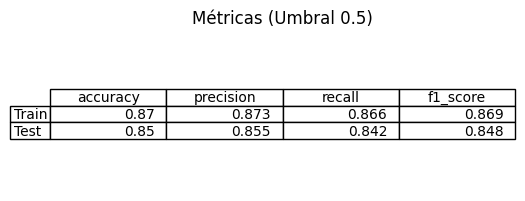

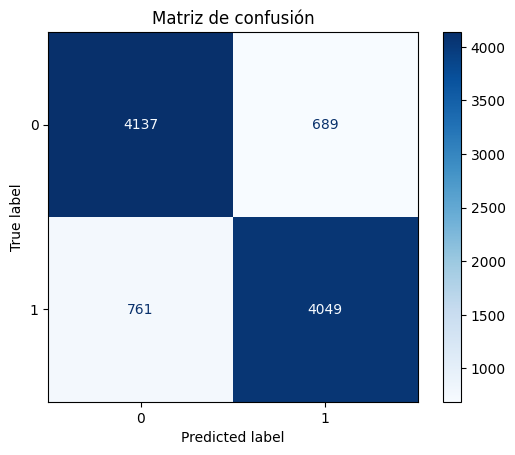


Buscando el mejor umbral para maximizar F1...
--> Mejor Umbral encontrado: 0.40
--> Nuevo F1 Score en Validación: 0.8497

Generando predicciones finales sobre Test...


In [10]:
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression

print("Iniciando RandomForest...")
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    min_samples_split=20,
    min_samples_leaf=15,
    max_features='sqrt',
    n_jobs=-1,
    random_state=42
)

print("Iniciando XGBoost...")
xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.03,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.6,
    gamma=1,
    reg_lambda=10.0,
    reg_alpha=1.0,
    eval_metric="logloss",
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

print("Iniciando Meta-modelo...")
meta_model = LogisticRegression(
    C=0.1,
    solver='liblinear',
    penalty='l1',
    max_iter=3000,
    class_weight="balanced",
    n_jobs=-1
)

stacked_model = StackingClassifier(
    estimators=[("rf", rf_model), ("xgb", xgb_model)],
    final_estimator=meta_model,
    cv=5,
    passthrough=False,
    n_jobs=-1
)

stacked_model.fit(X_train, y_train)

print("Evaluando modelo base...")
y_train_pred = stacked_model.predict(X_train)
y_val_pred = stacked_model.predict(X_val)
testear_clasificacion(y_train, y_val, y_train_pred, y_val_pred)

print("\nBuscando el mejor umbral para maximizar F1...")

y_val_probs = stacked_model.predict_proba(X_val)[:, 1]

thresholds = np.arange(0.1, 0.9, 0.01)
best_f1 = 0
best_thresh = 0.5

for thresh in thresholds:
    y_pred_temp = (y_val_probs >= thresh).astype(int)
    f1 = f1_score(y_val, y_pred_temp, pos_label=1)
    if f1 > best_f1:
        best_f1 = f1
        best_thresh = thresh

print(f"--> Mejor Umbral encontrado: {best_thresh:.2f}")
print(f"--> Nuevo F1 Score en Validación: {best_f1:.4f}")

print("\nGenerando predicciones finales sobre Test...")
y_test_probs = stacked_model.predict_proba(X_test_final)[:, 1]

y_test_pred_optimized = (y_test_probs >= best_thresh).astype(int)

data_test["sentimiento"] = le.inverse_transform(y_test_pred_optimized)

submission = data_test[["ID", "sentimiento"]]
submission.to_csv("submission.csv", index=False)

In [11]:
import joblib

print("Guardando modelo...")
joblib.dump(stacked_model, 'ensamble_model.joblib')

Guardando modelo...


['ensamble_model.joblib']